## Import Libraries
We import the necessary Python modules and PyTorch components that will be used throughout our project.  

**random** :   
    - Useful for controlling random behavior, though not heavily used here.  

**NumPy** :   
    - Complementary numerical library for array operations.  

**PyTorch (torch)** :   
    - Core library for handling tensors, automatic differentiation, and GPU computation. 


**nn and optim** :   
    - Provide pre-built neural network layers (e.g., Conv2d, Linear) and optimization methods (e.g., Adam).  


**torchvision.datasets** :   
    - Simplifies loading common datasets (such as FashionMNIST).  


**torchvision.transforms** :   
    - Preprocessing utilities (e.g., ToTensor()).  


**DataLoader** :   
    - Groups samples into batches for efficient training.  


**torchmetrics** :   
    - Offers ready-to-use metrics (Accuracy, Precision, Recall) that integrate well with PyTorch.  

In [1]:
# -------------------------
# Standard Library Imports
# -------------------------
import random                   # Python's built-in random module
import pandas as pd             # Panda for creating dataframe
import matplotlib.pyplot as plt # Visualizing the image
import seaborn as sns           # Visualizing the chart 

# -------------------------
# Third-Party Library Imports
# -------------------------
import numpy as np            # NumPy for numerical computations
import torch                  # PyTorch for tensor operations
import torch.nn as nn         # Neural network layers and functions
import torch.optim as optim   # Optimization algorithms

# -------------------------
# TorchVision and Transforms
# -------------------------
from torchvision import datasets              # Popular datasets (e.g., ImageFolder)
from torchvision.transforms import transforms # Image transformations (e.g., Resize, Normalize)

# -------------------------
# PyTorch Data Utilities
# -------------------------
from torch.utils.data import Dataset, DataLoader  # Custom dataset creation and batch loading

# -------------------------
# TorchMetrics for Evaluation
# -------------------------
from torchmetrics import Accuracy, Precision, Recall  # Standard evaluation metrics for classification

## Set Seed

In [2]:
# -------------------------
# Set the Seed for Reproducibility
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

## Define Transformer

In [3]:
# -------------------------
# Define Transformers for Training and Test Datasets
# -------------------------
# Define transforms with augmentation
train_transforms_1 = transforms.Compose([
    transforms.RandomAffine(
        degrees= 10,
        translate= (0.1, 0.1),
        scale= (0.9, 1.1),
        shear= 10
    ),
    transforms.RandomHorizontalFlip(p= 0.5),
    transforms.ColorJitter(brightness= 0.2, contrast= 0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p= 0.3,
        scale= (0.02, 0.2),
        ratio= (0.3, 3.3)
    )
])

train_transforms_2 = transforms.Compose([
    transforms.RandomAffine(
        degrees= 10,
        translate= (0.1, 0.1),
        scale= (0.9, 1.1),
        shear= 10
    ),
    transforms.ColorJitter(brightness= 0.2, contrast= 0.2),
    transforms.ToTensor()
])

train_transforms_3 = transforms.Compose([
    transforms.RandomHorizontalFlip(p= 0.5),
    transforms.ColorJitter(brightness= 0.2, contrast= 0.2),
    transforms.ToTensor(),
])

train_transforms_4 = transforms.Compose([
    transforms.RandomHorizontalFlip(p= 0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p= 0.3,
        scale= (0.02, 0.2),
        ratio= (0.3, 3.3)
    )
])

train_transforms_5 = transforms.Compose([
    transforms.ColorJitter(brightness= 0.2, contrast= 0.2),
    transforms.ToTensor()
])


test_transform = transforms.Compose([
    transforms.ToTensor()
])


## Load the Dataset
In this step, we download and load the **`FashionMNIST`** dataset, split into a training set (train=True) and a test set (train=False). We specify a root directory (./data) where the data will be stored, and use **`download=True`** to automatically fetch the dataset if it does not exist locally. By applying **`transforms.ToTensor()`**, each image is converted from a PIL image to a normalized PyTorch tensor, simplifying the process of feeding image data into our model.

In [4]:
# -------------------------
# Load the Training and Test Datasets
# -------------------------
train_data = datasets.FashionMNIST(
    root= './data', 
    train= True, 
    download= True, 
    transform= train_transforms_4
)
test_data = datasets.FashionMNIST(
    root= './data', 
    train= False, 
    download= True, 
    transform= test_transform
)

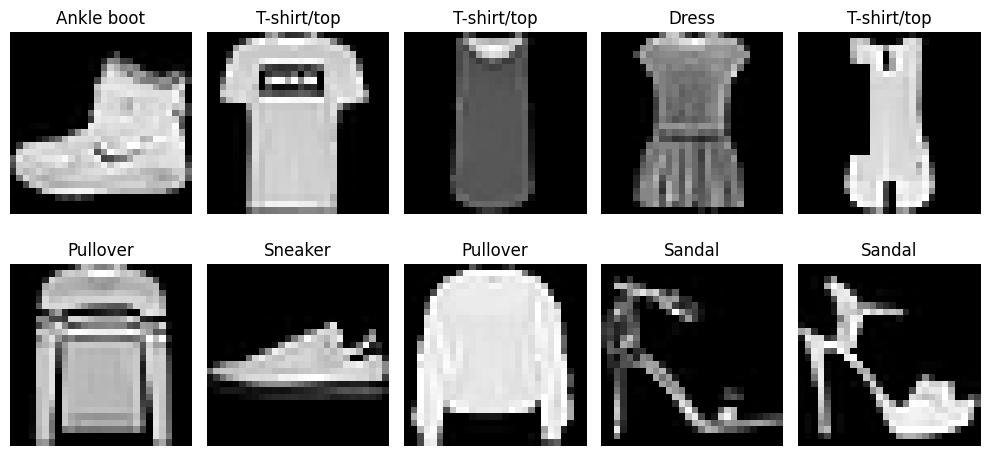

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))  # Create a 2x5 grid

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]  # Get image and label

    image = image.squeeze().numpy()  # Convert tensor to NumPy

    ax.imshow(image, cmap="gray")

    ax.set_title(f"{train_data.classes[label]}")

    ax.axis("off")

plt.tight_layout()

plt.show()


## Inspect the Dataset
Here, we gather crucial information about our datasets before training. We confirm the number of images available in each split and quickly inspect the shapes of the first training and test samples to ensure they match the expected **`one-channel`**, **`28×28`** **`format`**. We calculate the **`total number of pixels (28 * 28 = 784)`** to understand the raw input dimension for fully connected layers, and we also print out the class labels recognized by **`FashionMNIST`**, ultimately confirming there are **`10 unique categories`** to classify.

In [6]:
# -------------------------
# Basic Dataset Information
# -------------------------
# Print the number of samples in each dataset
print(f"Number of samples in train_data: {len(train_data)}")
print(f"Number of samples in test_data: {len(test_data)}", "\n")

# Inspect the first sample from each dataset
image, label = train_data[0]
image2, label2 = test_data[0]

# Print the shapes of the images
print(f"Train image shape: {image.shape}")
print(f"Test image shape: {image2.shape}", "\n")

# Calculate and print the number of features per image
# For FashionMNIST, each image is 1 channel with size 28 x 28.
num_features = image.shape[1] * image.shape[2]
print(f"Number of features per image: {num_features}", "\n")

# Check and print the available class labels
print(f"Unique class labels in train: {train_data.classes}")
print(f"Unique class labels in test: {test_data.classes}", "\n")
classes = train_data.classes

num_classes = len(train_data.classes)
print(f"Number of unique class labels in train: {num_classes}")

Number of samples in train_data: 60000
Number of samples in test_data: 10000 

Train image shape: torch.Size([1, 28, 28])
Test image shape: torch.Size([1, 28, 28]) 

Number of features per image: 784 

Unique class labels in train: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Unique class labels in test: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] 

Number of unique class labels in train: 10


## Defining the Convolutional Neural Network (CNN) 

This step constructs a **`convolutional neural network (CNN)`** for image classification. It consists of **`two convolutional blocks`** (each followed by ReLU activation and max pooling) that progressively extract spatial features from the input. Using **`Flatten`** transforms the 2D feature maps into a 1D vector, suitable for the final linear (fully connected) layer. We dynamically determine the output size of the feature extraction part by passing a dummy tensor, ensuring that our linear layer’s input dimension matches the extracted feature dimension.


In [7]:
# -------------------------
# Define the CNN Class
# -------------------------
class CNN_net(nn.Module):
    def __init__(self, num_classes):
        super(CNN_net, self).__init__()

        # Feature extraction layers: 
        self.feature_extraction = nn.Sequential(

            # 1) Convolution layer with 16 output channels, kernel 3x3, stride=1, padding=1
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),

            # 2) ReLU activation function
            nn.ReLU(),

            # 3) 2x2 Max Pooling with stride=2
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Flatten feature maps into a single vector
            nn.Flatten()                                                        
        )

        # Dynamically compute the number of features after the feature extraction layers.
        with torch.no_grad():
            # For FashionMNIST, this should be 28.
            image_size = train_data[0][0].shape[1]     

            # A dummy input
            sample_input = torch.zeros(1, 1, image_size, image_size)     

            # Extract Number of features       
            feature_map = self.feature_extraction(sample_input)

            # Flattened feature size
            num_features = feature_map.shape[1]

            # Debugging output                                 
            # print("Feature map shape:", feature_map.shape)                    

        # A single fully connected layer to map extracted features to class scores.
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        Forward pass:
        1) Extract features through the convolution, activation, and pooling layers.
        2) Flatten the features into a 1D vector.
        3) Pass the flattened vector to the fully connected layer for classification.
        """
        x = self.feature_extraction(x)                                          # Convolution & Pooling
        x = self.classifier(x)                                                  # Linear layer
        return x


## Prepare the Training DataLoader

We now wrap our training dataset in a **`DataLoader`**, which handles batching and data shuffling. Each iteration will yield a batch of **`10`** samples (images and labels), and **`shuffle=True`** ensures that data is randomized each epoch, improving the robustness of training by reducing any unintended ordering effects in the dataset.

In [8]:
# -------------------------
# Define the Training DataLoader and Test DataLoader
# -------------------------
# Create batches of size 10 from the training dataset, and shuffle the data.


def create_dataloader(dataset, batch_size, shuffle) :
    dataloader = DataLoader(
        dataset= dataset,
        batch_size= batch_size,
        shuffle= shuffle
    )

    return dataloader

# dataloader_train = create_dataloader(train_data, 20, True)
# dataloader_test = create_dataloader(test_data, 20, False)

# dataloader_train = DataLoader(
#     train_data,
#     batch_size= 20,
#     shuffle= True,
# )

# # Create a DataLoader for the test dataset (not defined above, so define it here)
# dataloader_test = DataLoader(
#     test_data,
#     batch_size= 20,
#     shuffle= False,
# )

## Define the Training Function
In this function, we iterate over the **`training data`** for a specified number of epochs, computing and **`backpropagating`** the **`cross-entropy loss`** after each forward pass. The criterion is **`nn.CrossEntropyLoss`**, well-suited to multi-class classification. Each batch updates the model’s parameters through the optimizer (**`optimizer.step()`**), and we track the average loss across all batches per epoch, providing a measure of training progress.

In [9]:
# -------------------------
# Define the Training Function
# -------------------------
def train_model(net, dataloader, optimizer, num_epochs):
    """
    Trains a given neural network for a specified number of epochs.
    
    Parameters:
    -----------
    optimizer: Torch Optimizer
        The optimizer responsible for updating model parameters.
    net: nn.Module
        The neural network model to be trained.
    num_epochs: int
        Number of training epochs.
    
    Returns:
    --------
    None
    """
    # Initialize the loss function
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        running_loss = 0.0  # Accumulate loss over each epoch
        num_processed = 0   # Track how many samples have been processed

        for features, labels in dataloader:
            # Zero out the gradients from the previous iteration
            optimizer.zero_grad()

            # Forward pass
            output = net(features)

            # Calculate loss
            loss = criterion(output, labels)

            # Backward pass
            loss.backward()

            # Update weights
            optimizer.step()

            # Accumulate the loss
            running_loss += loss.item()
            
            # Count the number of processed samples
            num_processed += len(labels)

        # Print the average training loss for this epoch
        train_loss = running_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss:.4f}")

## Instantiate and Train the Model

Here, we create our **`CNN instance`** and an **`Adam optimizer`**, which is known for its adaptive learning rate and efficient convergence properties. We set the **`learning rate to 0.01`** and call our training function for indicated epochs (more epochs are typically needed for better accuracy). During training, the optimizer updates the CNN’s weights, reducing the cross-entropy loss and hopefully improving model performance.



In [10]:
# -------------------------
# Instantiate the Model and Optimizer
# -------------------------
net = CNN_net(num_classes)             # Create an instance of the CNN
optimizer = optim.Adam(net.parameters(), lr=0.001)  # Use Adam optimizer with a learning rate of 0.001

In [11]:
def evaluate_model(net, dataloader, num_classes):
    """
    Evaluates the model on the given dataloader.
    Returns a dictionary with:
      - "accuracy" (float)
      - "precision_macro" (float)
      - "recall_macro" (float)
      - "precision_per_class" (list)
      - "recall_per_class" (list)
    """
    net.eval()
    
    # 1) Single-scalar metrics
    accuracy_metric = Accuracy(task = 'multiclass', num_classes = num_classes)
    precision_macro = Precision(task = 'multiclass', num_classes = num_classes, average = 'macro')
    recall_macro = Recall(task = 'multiclass', num_classes = num_classes, average = 'macro')
    
    # 2) Per-class metrics
    precision_perclass = Precision(task = 'multiclass', num_classes = num_classes, average = None)
    recall_perclass = Recall(task = 'multiclass', num_classes = num_classes, average = None )
    
    # Accumulate predictions
    with torch.no_grad():
        for features, labels in dataloader:
            outputs = net(features)
            preds = torch.argmax(outputs, dim=-1)

            # Update each metric
            accuracy_metric.update(preds, labels)
            precision_macro.update(preds, labels)
            recall_macro.update(preds, labels)
            precision_perclass.update(preds, labels)
            recall_perclass.update(preds, labels)

    # 3) Compute final metrics
    accuracy_value        = accuracy_metric.compute().item()
    precision_macro_value = precision_macro.compute().item()
    recall_macro_value    = recall_macro.compute().item()
    
    # per-class -> Tensors of shape [num_classes]
    precision_perclass_vals = precision_perclass.compute().tolist()
    recall_perclass_vals    = recall_perclass.compute().tolist()
    
    # Return everything in a dictionary
    results = {
        "accuracy": accuracy_value,
        "precision_macro": precision_macro_value,
        "recall_macro": recall_macro_value,
        "precision_per_class": precision_perclass_vals,
        "recall_per_class": recall_perclass_vals
    }
    
    return results


In [13]:
def train_and_evaluate_multiple_runs(transform, transform_name, seeds, num_epochs):
    """
    Runs multiple training/evaluation cycles for a given transform across multiple seeds.
    Returns:
      - summary: Overall mean & std metrics (accuracy, macro precision, macro recall)
      - summary_per_class: Mean & std for per-class precision & recall
    """
    # 1. Prepare train/test datasets with the given transform
    train_dataset = datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root='./data',
        train=False,
        download=True,
        transform=test_transform
    )
    
    dataloader_train = create_dataloader(train_dataset, 20, True)
    dataloader_test = create_dataloader(test_dataset, 20, False)

    # 2. Lists to store MACRO metrics from each run
    acc_scores = []
    prec_mac_scores = []
    rec_mac_scores = []

    # 3. Lists to store per-class precision and recall metrics
    prec_per_class_scores = []
    rec_per_class_scores = []

    # 4. Loop over seeds
    for seed in seeds:
        print(f"\n[Transform = {transform_name}] -- Running with seed={seed}")
        set_seed(seed)
        
        # Fresh model & optimizer each run
        net = CNN_net(num_classes=10)
        optimizer = optim.Adam(net.parameters(), lr=0.001)
        
        # Train
        train_model(net, dataloader_train, optimizer, num_epochs=num_epochs)
        
        # Evaluate -> returns both macro + per-class
        results = evaluate_model(net, dataloader_test, num_classes=10)
        
        # Store macro metrics
        acc_scores.append(results["accuracy"])
        prec_mac_scores.append(results["precision_macro"])
        rec_mac_scores.append(results["recall_macro"])

        # Store per-class precision & recall
        prec_per_class_scores.append(results["precision_per_class"])
        rec_per_class_scores.append(results["recall_per_class"])
        
        print(f"Final Test (seed={seed}) -> "
              f"Acc: {results['accuracy']:.4f}, Prec (macro): {results['precision_macro']:.4f}, "
              f"Rec (macro): {results['recall_macro']:.4f}")

    # 5. Compute summary (overall metrics)
    summary = {
        'transform': transform_name,
        'mean_accuracy': np.mean(acc_scores),
        'std_accuracy': np.std(acc_scores),
        'mean_precision': np.mean(prec_mac_scores),
        'std_precision': np.std(prec_mac_scores),
        'mean_recall': np.mean(rec_mac_scores),
        'std_recall': np.std(rec_mac_scores),
        'num_runs': len(seeds),
    }
    
    # 6. Compute per-class summary
    summary_per_class = {
        'transform': transform_name,
        'mean_precision_per_class': np.mean(prec_per_class_scores, axis=0).tolist(),
        'std_precision_per_class': np.std(prec_per_class_scores, axis=0).tolist(),
        'mean_recall_per_class': np.mean(rec_per_class_scores, axis=0).tolist(),
        'std_recall_per_class': np.std(rec_per_class_scores, axis=0).tolist(),
    }
    
    return summary, summary_per_class


In [14]:
# Example seeds to run multiple times
seeds = np.arange(10, 21, 1).tolist()

# Dictionary of transforms to evaluate
transform_candidates = {
    "transform_1" : train_transforms_1,
    "transform_2" : train_transforms_2,
    "transform_3" : train_transforms_3,
    "transform_4" : train_transforms_4,
    "transform_5" : train_transforms_5,
    "transform_none" : transforms.ToTensor(),
}

# Lists to store results
all_results = []
all_results_per_class = []

# Loop through each transform, run multiple times, collect results
for t_name, t_object in transform_candidates.items():
    summary, summary_per_class = train_and_evaluate_multiple_runs(
        transform=t_object,
        transform_name=t_name,
        seeds=seeds,
        num_epochs=10
    )
    all_results.append(summary)
    all_results_per_class.append(summary_per_class)

# 1. Create DataFrame for overall results
df_summary = pd.DataFrame(all_results)

# 2. Convert per-class metrics into a structured DataFrame
df_summary_per_class = pd.DataFrame(all_results_per_class)

# Expand lists in `df_summary_per_class` to multiple columns
precision_cols = [f"precision_class_{i}" for i in range(10)]
recall_cols = [f"recall_class_{i}" for i in range(10)]

df_summary_per_class[precision_cols] = pd.DataFrame(df_summary_per_class["mean_precision_per_class"].tolist())
df_summary_per_class[recall_cols] = pd.DataFrame(df_summary_per_class["mean_recall_per_class"].tolist())

# Drop the original list columns since they are now expanded
df_summary_per_class.drop(columns=["mean_precision_per_class", "mean_recall_per_class"], inplace=True)

# (Optional) Save results to CSV
df_summary.to_csv("multi_run_summary_2.csv", index=False)
df_summary_per_class.to_csv("multi_run_summary_per_class_2.csv", index=False)


[Transform = transform_1] -- Running with seed=10
Epoch 1/10, Training Loss: 0.7963
Epoch 2/10, Training Loss: 0.6132
Epoch 3/10, Training Loss: 0.5655
Epoch 4/10, Training Loss: 0.5341
Epoch 5/10, Training Loss: 0.5143
Epoch 6/10, Training Loss: 0.4973
Epoch 7/10, Training Loss: 0.4869
Epoch 8/10, Training Loss: 0.4783
Epoch 9/10, Training Loss: 0.4653
Epoch 10/10, Training Loss: 0.4616
Final Test (seed=10) -> Acc: 0.8770, Prec (macro): 0.8805, Rec (macro): 0.8770

[Transform = transform_1] -- Running with seed=11
Epoch 1/10, Training Loss: 0.7894
Epoch 2/10, Training Loss: 0.6114
Epoch 3/10, Training Loss: 0.5580
Epoch 4/10, Training Loss: 0.5278
Epoch 5/10, Training Loss: 0.5055
Epoch 6/10, Training Loss: 0.4900
Epoch 7/10, Training Loss: 0.4741
Epoch 8/10, Training Loss: 0.4693
Epoch 9/10, Training Loss: 0.4562
Epoch 10/10, Training Loss: 0.4539
Final Test (seed=11) -> Acc: 0.8754, Prec (macro): 0.8768, Rec (macro): 0.8754

[Transform = transform_1] -- Running with seed=12
Epoch 1

In [15]:
df_summary

,transform,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,num_runs
0,transform_1,0.873191,0.004542,0.874382,0.004015,0.873191,0.004542,11
1,transform_2,0.880400,0.005655,0.881472,0.004413,0.880400,0.005655,11
2,transform_3,0.911000,0.002730,0.911737,0.002540,0.911000,0.002730,11
3,transform_4,0.911273,0.002775,0.912293,0.002484,0.911273,0.002775,11
4,transform_5,0.910364,0.002998,0.911302,0.002390,0.910364,0.002998,11
5,transform_none,0.911927,0.003155,0.912575,0.003002,0.911927,0.003155,11


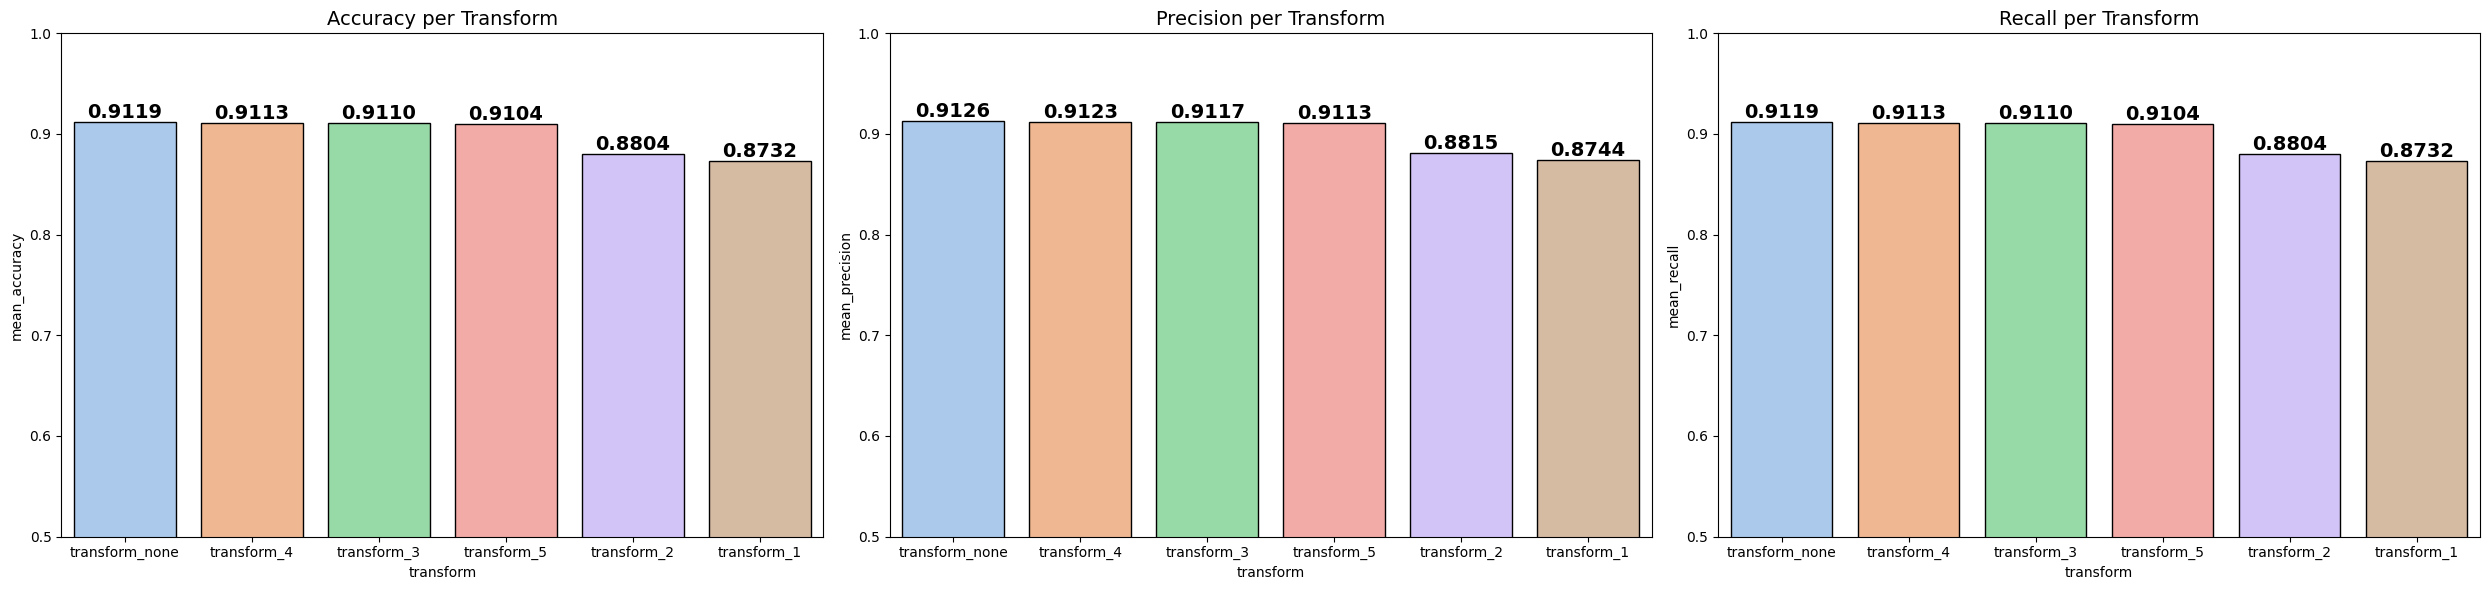

In [16]:
sns.set_palette("pastel")

fig, axes = plt.subplots(1, 3, figsize=(25, 6))

metrics = ["mean_accuracy", "mean_precision", "mean_recall"]
titles = ["Accuracy per Transform", "Precision per Transform", "Recall per Transform"]

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    sns.barplot(
        data= df_summary.sort_values(by=metric, ascending= False), 
        x= "transform", 
        y= metric, 
        hue= "transform", 
        ax= ax, 
        edgecolor= "black"  # Black border for bars
)
    
    ax.set_ylim(0.5, 1.0)  
    
    ax.set_title(titles[i], fontsize=14)
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}',  
                    (p.get_x() + p.get_width() / 2., p.get_height()),  
                    ha='center', va='bottom', fontsize=14, color='black', weight= "bold")

plt.tight_layout()
plt.show()
